# Distance-Based Redundancy Analysis (dbRDA) in R

## Overview

dbRDA is a **constrained ordination** method: it finds axes that maximize the community variance explained by a set of environmental predictors. Unlike NMDS and PCA (unconstrained ordination), the axes in dbRDA are directly tied to the environmental variables.

**Workflow:**
1. Compute a dissimilarity matrix (e.g., Bray-Curtis)
2. Apply principal coordinates analysis (PCoA) to get Euclidean coordinates
3. Run RDA on the PCoA scores constrained by environmental predictors

| Method | Constrained? | Input | Use Case |
|---|---|---|---|
| PCA | No | Raw variables | Summarize correlated variables |
| NMDS | No | Dissimilarity | Visualize community structure |
| dbRDA | Yes | Dissimilarity + env. predictors | Explain community variation with env. variables |
| RDA | Yes | Raw community + env. | Hellinger-transformed species data |
| CCA | Yes | Raw community + env. | Species data assumed unimodal responses |

## Applications by Sector

| Sector | Example |
|---|---|
| **Ecology** | Which water chemistry variables best explain invertebrate community composition across sites? How much compositional variance is attributable to pH vs. nutrient loading vs. physical disturbance? |
| **Healthcare** | Which clinical variables explain microbiome composition differences across patient groups? |
| **Finance** | Which macroeconomic factors explain portfolio composition variation across funds? |

---

## Setup

In [1]:
library(tidyverse)
library(ggplot2)
library(vegan)
library(ggrepel)

set.seed(42)

# ── Simulate data ─────────────────────────────────────────────────────────────
n_sites <- 50; n_sp <- 20
habitat <- rep(c("reference", "degraded", "restored"), length.out = n_sites)

# Environmental predictors drive community composition
env_df <- tibble(
  site        = paste0("site", 1:n_sites),
  habitat     = factor(habitat, levels = c("reference", "degraded", "restored")),
  pH          = c(rnorm(17, 7.8, 0.3), rnorm(17, 6.5, 0.5), rnorm(16, 7.2, 0.4)),
  nitrate     = c(rnorm(17, 0.5, 0.2), rnorm(17, 3.5, 0.8), rnorm(16, 1.5, 0.4)),
  turbidity   = c(rnorm(17, 3,   1.0), rnorm(17,12,   2.5), rnorm(16, 6,   1.5)),
  dissolved_O2 = c(rnorm(17, 9.5, 0.8), rnorm(17, 6, 1.5), rnorm(16, 8, 1.0))
)

# Community composition driven by environment
env_effect <- scale(env_df %>% select(pH, nitrate, turbidity, dissolved_O2))
comm_latent <- env_effect %*% matrix(rnorm(4 * n_sp), 4, n_sp) + matrix(rnorm(n_sites * n_sp, 0, 0.8), n_sites, n_sp)
comm_mat <- matrix(rpois(n_sites * n_sp, exp(1.5 + comm_latent * 0.4)),
                   n_sites, n_sp)
rownames(comm_mat) <- env_df$site
colnames(comm_mat) <- paste0("sp", 1:n_sp)

dist_bray <- vegan::vegdist(comm_mat, method = "bray")
env_mat   <- env_df %>% select(pH, nitrate, turbidity, dissolved_O2) %>% as.matrix()
rownames(env_mat) <- env_df$site

Warning message:
"package 'tidyverse' was built under R version 4.4.3"
Warning message:
"package 'ggplot2' was built under R version 4.4.3"
Warning message:
"package 'purrr' was built under R version 4.4.3"
Warning message:
"package 'dplyr' was built under R version 4.4.3"
Warning message:
"package 'stringr' was built under R version 4.4.3"
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Warning message:
"package 'vegan' was built under R version 4.4.3"
Loading required package: permute



---

## Fitting dbRDA with `vegan::capscale()`

In [2]:
# ── Unconstrained PCoA (for comparison) ──────────────────────────────────────
pcoa <- vegan::capscale(dist_bray ~ 1)

# ── Constrained dbRDA: community ~ environmental predictors ───────────────────
dbrda_full <- vegan::capscale(
  dist_bray ~ pH + nitrate + turbidity + dissolved_O2,
  data = env_df,
  dist = "bray"   # passed to vegdist if raw matrix provided instead of dist object
)
summary(dbrda_full)

# ── Key summary output ────────────────────────────────────────────────────────
# Constrained: variance explained by the environmental predictors
# Unconstrained: residual variance not explained by predictors
# CAP axes (constrained): axes tied to environmental predictors
# PC axes (unconstrained): residual structure

# ── Proportion of variance explained ─────────────────────────────────────────
eig <- vegan::eigenvals(dbrda_full)
total_var    <- sum(eig[eig > 0])
constrained  <- sum(eig[names(eig) %in% grep("CAP", names(eig), value=TRUE)])

cat(sprintf("Total variance: %.4f\n", total_var))
cat(sprintf("Constrained (explained by env): %.4f (%.1f%%)\n",
            constrained, constrained/total_var*100))
cat(sprintf("Unconstrained (residual): %.4f (%.1f%%)\n",
            total_var - constrained, (total_var - constrained)/total_var*100))


Call:
vegan::capscale(formula = dist_bray ~ pH + nitrate + turbidity +      dissolved_O2, data = env_df, distance = "bray") 

Partitioning of squared Bray distance:
              Inertia Proportion
Total           7.285     1.0000
Constrained     4.004     0.5497
Unconstrained   3.281     0.4503

Eigenvalues, and their contribution to the squared Bray distance 

Importance of components:
                        CAP1    CAP2    CAP3    CAP4   MDS1    MDS2   MDS3
Eigenvalue            3.2485 0.37048 0.28772 0.09758 0.7541 0.32107 0.2623
Proportion Explained  0.4459 0.05086 0.03949 0.01339 0.1035 0.04407 0.0360
Cumulative Proportion 0.4459 0.49677 0.53626 0.54966 0.6532 0.69724 0.7332
                         MDS4    MDS5    MDS6    MDS7    MDS8    MDS9   MDS10
Eigenvalue            0.21066 0.19773 0.17601 0.15333 0.13505 0.12981 0.11530
Proportion Explained  0.02892 0.02714 0.02416 0.02105 0.01854 0.01782 0.01583
Cumulative Proportion 0.76216 0.78930 0.81346 0.83451 0.85304 0.87086 0.88

Total variance: 7.2850
Constrained (explained by env): 4.0042 (55.0%)
Unconstrained (residual): 3.2808 (45.0%)


---

## Testing Significance

In [3]:
# ── Global permutation test: is the constrained model significant? ─────────────
anova_global <- vegan::anova.cca(dbrda_full, permutations = 999)
print(anova_global)

# ── Test each axis separately ─────────────────────────────────────────────────
anova_axes <- vegan::anova.cca(dbrda_full, by = "axis", permutations = 999)
print(anova_axes)
# Significant axes: contain real community structure tied to environment

# ── Test each term (marginal) ─────────────────────────────────────────────────
anova_terms <- vegan::anova.cca(dbrda_full, by = "margin", permutations = 999)
print(anova_terms)
# Which specific environmental variables significantly explain community variance?
# p < 0.05 + high F: this variable is an important driver

Permutation test for capscale under reduced model
Permutation: free
Number of permutations: 999

Model: vegan::capscale(formula = dist_bray ~ pH + nitrate + turbidity + dissolved_O2, data = env_df, distance = "bray")
         Df SumOfSqs      F Pr(>F)    
Model     4   4.0042 13.731  0.001 ***
Residual 45   3.2808                  
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1
Permutation test for capscale under reduced model
Forward tests for axes
Permutation: free
Number of permutations: 999

Model: vegan::capscale(formula = dist_bray ~ pH + nitrate + turbidity + dissolved_O2, data = env_df, distance = "bray")
         Df SumOfSqs       F Pr(>F)    
CAP1      1   3.2485 44.5570  0.001 ***
CAP2      1   0.3705  5.1946  0.001 ***
CAP3      1   0.2877  4.1219  0.001 ***
CAP4      1   0.0976  1.4276  0.118    
Residual 45   3.2808                   
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1
Permutation test for capscale under reduced model
Ma

---

## Variable Selection: Forward Selection

In [4]:
# ── Null model (no constraints) ───────────────────────────────────────────────
dbrda_null <- vegan::capscale(dist_bray ~ 1, data = env_df)

# ── Forward selection with double stopping criterion ──────────────────────────
# Blanchet et al. (2008): stop when (1) p > 0.05 OR (2) R² exceeds global R²
# This controls both type I error and overfitting
fwd_sel <- vegan::ordiR2step(
  dbrda_null,
  scope        = formula(dbrda_full),
  direction    = "forward",
  permutations = 499,   # lower for speed; use 999 for publication
  R2scope      = TRUE   # stops when R² exceeds global model R²
)
print(fwd_sel)
# Shows which variables were added at each step and their contribution

# ── Fit model with selected variables ────────────────────────────────────────
dbrda_sel <- update(fwd_sel)   # or refit manually with selected terms
anova_sel <- vegan::anova.cca(dbrda_sel, by = "margin", permutations = 999)
print(anova_sel)

Step: R2.adj= 0 
Call: dist_bray ~ 1 
 
                R2.adjusted
<All variables>   0.5096247
+ nitrate         0.4138375
+ pH              0.3471305
+ dissolved_O2    0.3297020
+ turbidity       0.3287589
<model>           0.0000000

          Df    AIC      F Pr(>F)   
+ nitrate  1 74.542 35.595  0.002 **
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Step: R2.adj= 0.4138375 
Call: dist_bray ~ nitrate 
 
                R2.adjusted
<All variables>   0.5096247
+ dissolved_O2    0.4580957
+ pH              0.4567065
+ turbidity       0.4193806
<model>           0.4138375

               Df    AIC      F Pr(>F)   
+ dissolved_O2  1 71.564 4.9202  0.008 **
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Step: R2.adj= 0.4580957 
Call: dist_bray ~ nitrate + dissolved_O2 
 
                R2.adjusted
<All variables>   0.5096247
+ pH              0.5015415
+ turbidity       0.4650793
<model>           0.4580957

     Df   AIC      F Pr(>F)   
+ pH 

---

## Ordination Triplot

A dbRDA triplot shows sites, species (or response variables), and environmental predictors simultaneously.

Warning message:
"Removed 30 rows containing missing values or values outside the scale range
(`geom_point()`)."
Warning message:
"Removed 30 rows containing missing values or values outside the scale range
(`geom_text_repel()`)."


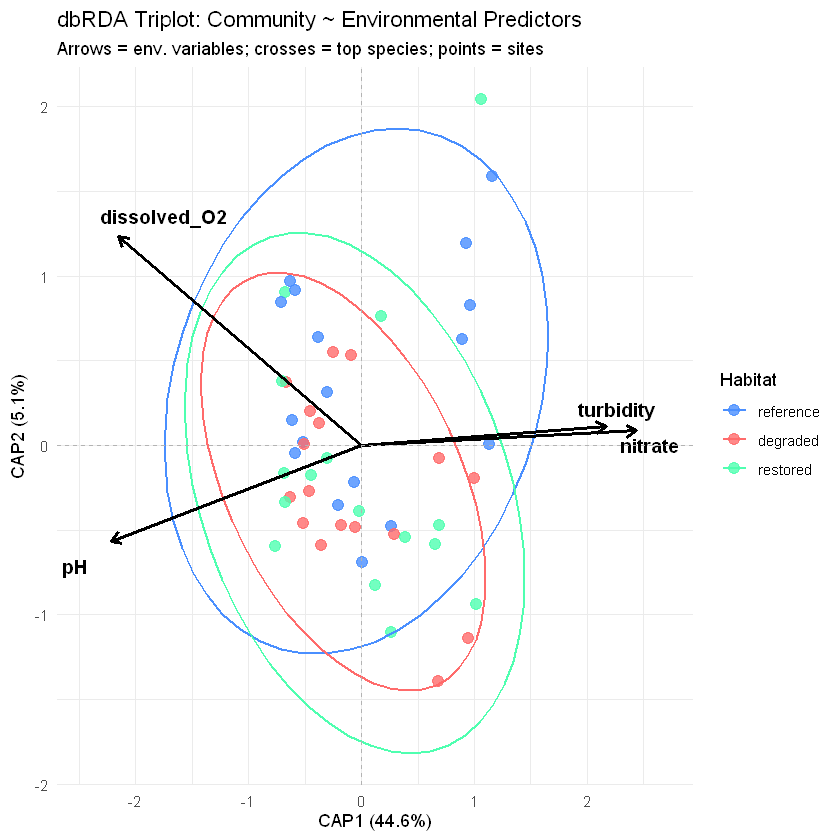

In [5]:
# ── Extract scores ────────────────────────────────────────────────────────────
site_scores <- as.data.frame(vegan::scores(dbrda_full, display = "sites",
                                            choices = 1:2)) %>%
  rownames_to_column("site") %>%
  left_join(env_df %>% select(site, habitat), by = "site")

# Biplot scores = environmental variable vectors
env_scores <- as.data.frame(vegan::scores(dbrda_full, display = "bp",
                                           choices = 1:2)) %>%
  rownames_to_column("variable")

# Species scores
sp_scores <- as.data.frame(vegan::scores(dbrda_full, display = "species",
                                          choices = 1:2)) %>%
  rownames_to_column("species") %>%
  mutate(dist = sqrt(CAP1^2 + CAP2^2)) %>%
  slice_max(dist, n = 8)  # top 8 species

# Variance explained per axis
eig2 <- vegan::eigenvals(dbrda_full)
cap_pct <- round(eig2[1:2] / sum(eig2[eig2>0]) * 100, 1)

# ── Triplot ───────────────────────────────────────────────────────────────────
scale_env <- 2.5
ggplot() +
  # Sites
  geom_point(data = site_scores,
             aes(x = CAP1, y = CAP2, color = habitat),
             size = 3, alpha = 0.8) +
  stat_ellipse(data = site_scores,
               aes(x = CAP1, y = CAP2, color = habitat),
               level = 0.95, linewidth = 0.7) +
  # Environmental vectors
  geom_segment(data = env_scores,
               aes(x = 0, y = 0, xend = CAP1*scale_env, yend = CAP2*scale_env),
               arrow = arrow(length = unit(0.25, "cm")),
               color = "black", linewidth = 0.9) +
  ggrepel::geom_text_repel(data = env_scores,
                            aes(x = CAP1*scale_env*1.1, y = CAP2*scale_env*1.1,
                                label = variable),
                            size = 4, fontface = "bold") +
  # Species (top 8)
  geom_point(data = sp_scores,
             aes(x = CAP1, y = CAP2),
             shape = 3, size = 2.5, color = "gray40") +
  ggrepel::geom_text_repel(data = sp_scores,
                            aes(x = CAP1, y = CAP2, label = species),
                            size = 2.8, color = "gray30", fontface = "italic") +
  geom_hline(yintercept = 0, linetype = "dashed", color = "gray70") +
  geom_vline(xintercept = 0, linetype = "dashed", color = "gray70") +
  scale_color_manual(values = c("#4a8fff", "#ff6b6b", "#4fffb0")) +
  labs(
    title = "dbRDA Triplot: Community ~ Environmental Predictors",
    subtitle = "Arrows = env. variables; crosses = top species; points = sites",
    x = sprintf("CAP1 (%.1f%%)", cap_pct[1]),
    y = sprintf("CAP2 (%.1f%%)", cap_pct[2]),
    color = "Habitat"
  ) +
  theme_minimal()

---

## Variance Partitioning

`vegan::varpart()` partitions community variance among two or more sets of predictors, showing unique and shared contributions.


Partition of variance in RDA 

Call: vegan::varpart(Y = comm_hell, X = chemistry, physical)

Explanatory tables:
X1:  chemistry
X2:  physical 

No. of explanatory tables: 2 
Total variation (SS): 10.449 
            Variance: 0.21325 
No. of observations: 50 

Partition table:
                     Df R.squared Adj.R.squared Testable
[a+c] = X1            2   0.53945       0.51985     TRUE
[b+c] = X2            2   0.50493       0.48386     TRUE
[a+b+c] = X1+X2       4   0.62676       0.59358     TRUE
Individual fractions                                    
[a] = X1|X2           2                 0.10972     TRUE
[b] = X2|X1           2                 0.07373     TRUE
[c]                   0                 0.41013    FALSE
[d] = Residuals                         0.40642    FALSE
---
Use function 'rda' to test significance of fractions of interest
Permutation test for capscale under reduced model
Permutation: free
Number of permutations: 999

Model: vegan::capscale(formula = comm_hell

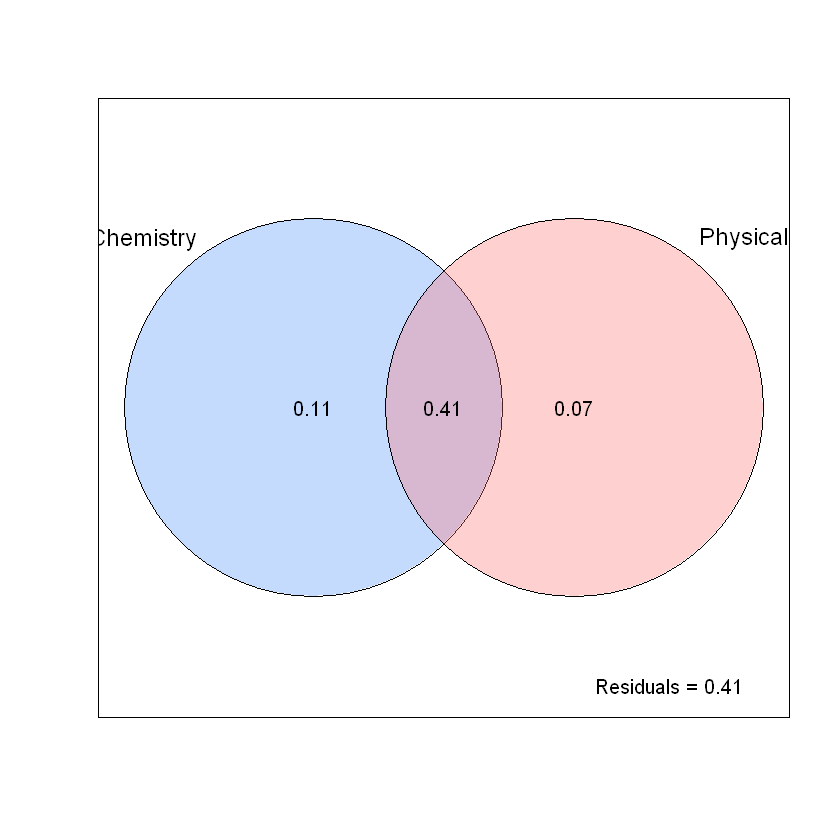

In [6]:
# ── Partition variance: chemistry vs. physical variables ─────────────────────
chemistry <- env_df %>% select(pH, nitrate) %>% as.data.frame()
physical  <- env_df %>% select(turbidity, dissolved_O2) %>% as.data.frame()

# Use Hellinger-transformed community for varpart (requires raw matrix, not dist)
comm_hell <- vegan::decostand(comm_mat, method = "hellinger")

vp <- vegan::varpart(comm_hell, chemistry, physical)
print(vp)
plot(vp,
     Xnames = c("Chemistry", "Physical"),
     bg     = c("#4a8fff", "#ff6b6b"),
     alpha  = 80)
# [a]: unique variance explained by chemistry
# [b]: shared variance (cannot be attributed to either)
# [c]: unique variance explained by physical variables
# [d]: unexplained (residual)

# ── Test unique fractions with partial dbRDA ──────────────────────────────────
# Unique contribution of chemistry, controlling for physical
dbrda_chem_partial <- vegan::capscale(
  comm_hell ~ pH + nitrate + Condition(turbidity + dissolved_O2),
  data = env_df
)
anova_chem_unique <- vegan::anova.cca(dbrda_chem_partial, permutations = 999)
print(anova_chem_unique)

---

## Reporting Results

In [7]:
cat("=== Global test ===\n")
print(anova_global)
cat("\n=== Marginal tests per term ===\n")
print(anova_terms)

# Standard reporting format:
# "Distance-based redundancy analysis (dbRDA; Bray-Curtis dissimilarity;
#  vegan::capscale) was used to identify environmental variables associated
#  with invertebrate community composition. The constrained model explained
#  XX% of total community variance (global permutation test: F = X.XX,
#  p = .XXX, 999 permutations). Marginal tests indicated that pH
#  (F = X.XX, p = .XXX) and nitrate (F = X.XX, p = .XXX) were significant
#  predictors of community composition, while turbidity was not
#  (F = X.XX, p = .XXX). Variance partitioning showed that water
#  chemistry variables uniquely explained XX% of community variance,
#  while physical variables uniquely explained XX%."

=== Global test ===
Permutation test for capscale under reduced model
Permutation: free
Number of permutations: 999

Model: vegan::capscale(formula = dist_bray ~ pH + nitrate + turbidity + dissolved_O2, data = env_df, distance = "bray")
         Df SumOfSqs      F Pr(>F)    
Model     4   4.0042 13.731  0.001 ***
Residual 45   3.2808                  
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

=== Marginal tests per term ===
Permutation test for capscale under reduced model
Marginal effects of terms
Permutation: free
Number of permutations: 999

Model: vegan::capscale(formula = dist_bray ~ pH + nitrate + turbidity + dissolved_O2, data = env_df, distance = "bray")
             Df SumOfSqs      F Pr(>F)    
pH            1   0.3776 5.1786  0.001 ***
nitrate       1   0.2806 3.8488  0.010 ** 
turbidity     1   0.1282 1.7582  0.122    
dissolved_O2  1   0.3893 5.3397  0.001 ***
Residual     45   3.2808                  
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '

---

## Common Pitfalls

**1. Not testing model significance before interpreting the triplot**  
A dbRDA triplot is always produced regardless of whether the constraints explain any real variance. Always run the global permutation test first.

**2. Overfitting with many predictors**  
Including many uncorrelated environmental predictors will inflate the constrained variance. Use forward selection with the double stopping criterion (`ordiR2step`) to select a parsimonious model.

**3. Confusing constrained and total variance**  
The proportion of variance explained by the constrained axes is a fraction of *total* community variance, not of explained variance. Always report both the constrained % and the total unexplained residual.

**4. Not conditioning on nuisance variables**  
If you want to test the effect of habitat type after controlling for season, use `Condition(season)` in the formula — this is the multivariate equivalent of an ANCOVA.

**5. Using `capscale()` directly on a community matrix without distance specification**  
Without specifying a dissimilarity metric, `capscale()` computes Euclidean distances on the raw data. For species abundances, always specify `dist = "bray"` or pre-compute the distance matrix.

---
*r_methods_library · Samantha McGarrigle · [github.com/samantha-mcgarrigle](https://github.com/samantha-mcgarrigle)*